<a href="https://colab.research.google.com/github/K-Tanaka8/lightgbm_demand_forecast/blob/main/lightgbm_demand_forecast_sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:

'''
#  簡易需要予測サンプル (LightGBM)
このノートブックは、Google Colab上で動作する「LightGBMによる簡易需要予測」のサンプルです。

- ダミーデータで動作確認済み
- Google Colabでそのまま動かせます
- このリポジトリのコードはポートフォリオ用です。 閲覧は自由ですが、商用利用・再配布は不可です。
'''

'\n#  簡易需要予測サンプル (LightGBM)\nこのノートブックは、Google Colab上で動作する「LightGBMによる簡易需要予測」のサンプルです。\n\n- ダミーデータで動作確認済み\n- Google Colabでそのまま動かせます\n- このリポジトリのコードはポートフォリオ用です。 閲覧は自由ですが、商用利用・再配布は不可です。\n'

Fold1 RMSE: 11.09
Fold1 MAE: 8.93
Fold2 RMSE: 9.39
Fold2 MAE: 7.73
Fold3 RMSE: 16.53
Fold3 MAE: 14.35

CV平均結果
RMSE mean: 12.34
MAE mean: 10.34


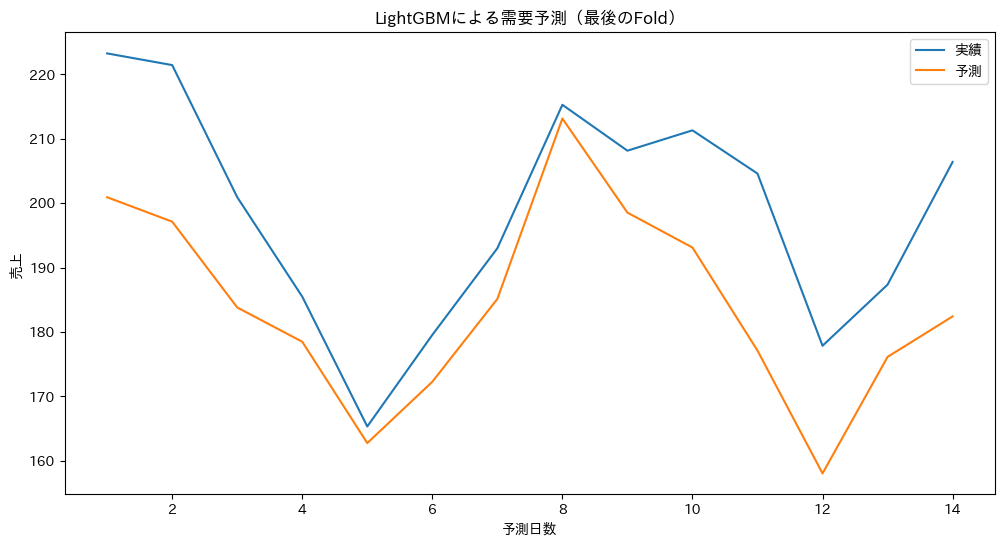

In [23]:
# =======================================================
# 1 日本語対応（最も安定する方法）
# =======================================================

!pip install -q japanize-matplotlib

import japanize_matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# =======================================================
# 2 サンプルデータ作成
# =======================================================

np.random.seed(42)

dates = pd.date_range(start="2023-01-01", periods=365)

sales = (
    200
    + np.sin(np.arange(365) * 2 * np.pi / 7) * 20
    + np.sin(np.arange(365) * 2 * np.pi / 365) * 30
    + np.random.normal(0, 10, 365)
)

df = pd.DataFrame({
    "date": dates,
    "sales": sales
})

# =======================================================
# 3 特徴量作成
# =======================================================

df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek

# ラグ特徴量
df["lag_7"] = df["sales"].shift(7)

# プロモーション
df["promotion"] = np.random.randint(0, 2, len(df))

# 在庫
df["stock"] = 500 + np.random.normal(0, 50, len(df))

# 欠損削除
df = df.dropna()

# =======================================================
# 4 学習データ
# =======================================================

features = [
    "month",
    "day_of_week",
    "lag_7",
    "promotion",
    "stock"
]

X = df[features]
y = df["sales"]

# =======================================================
# 5 Expanding Window CV
# =======================================================

horizon = 14
n_folds = 3

rmse_list = []
mae_list = []

for i in range(n_folds):
    # Foldごとに horizon 日ずつテストセットをスライド
    train_end = len(df) - horizon * (n_folds - i)

    X_train = X.iloc[:train_end]
    y_train = y.iloc[:train_end]

    X_test = X.iloc[train_end:train_end + horizon]
    y_test = y.iloc[train_end:train_end + horizon]

    # ----------------------
    # LightGBM モデル
    # ----------------------

    model = lgb.LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        verbosity=-1
    )

    model.fit(X_train, y_train)

    # ----------------------
    # 予測
    # ----------------------

    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)

    rmse_list.append(rmse)
    mae_list.append(mae)

    print(f"Fold{i+1} RMSE: {rmse:.2f}")
    print(f"Fold{i+1} MAE: {mae:.2f}")

    # 最後のfoldだけ保存
    if i == n_folds - 1:
        last_y_test = y_test
        last_pred = pred


# =======================================================
# 6 評価表示
# =======================================================

print()
print("CV平均結果")

print(f"RMSE mean: {np.mean(rmse_list):.2f}")
print(f"MAE mean: {np.mean(mae_list):.2f}")

# =======================================================
# 7 予測グラフ
# =======================================================

plt.figure(figsize=(12,6))

x = np.arange(1, len(last_pred) + 1)

plt.plot(x, last_y_test.to_numpy(), label="実績")
plt.plot(x, last_pred, label="予測")

plt.title("LightGBMによる需要予測（最後のFold）")
plt.xlabel("予測日数")
plt.ylabel("売上")

plt.legend()

plt.show()



### ⚙ Feature Importance

LightGBM モデルで予測に寄与した特徴量を可視化しました。  
- このサンプルデータでは、**stock, lag_7 ** など、在庫や直近の売上データが強く影響していることがわかります。  
- 曜日・月・休日などのカレンダー情報も一定の重要度を持っており、季節性や週次パターンが予測に貢献しています。  

> この分析から、以下の示唆が得られます：  
> 1. 在庫や過去の売上データ（ラグ特徴量）が予測に最も重要  
> 2. カレンダー情報を追加することでモデルの精度向上が期待できる

今後の改善案：
- 異なる期間のラグ（1日,14日,31日）やシーズナリティを特徴量に追加  
- ラグ特徴量とカレンダー特徴量の相互作用を考慮  

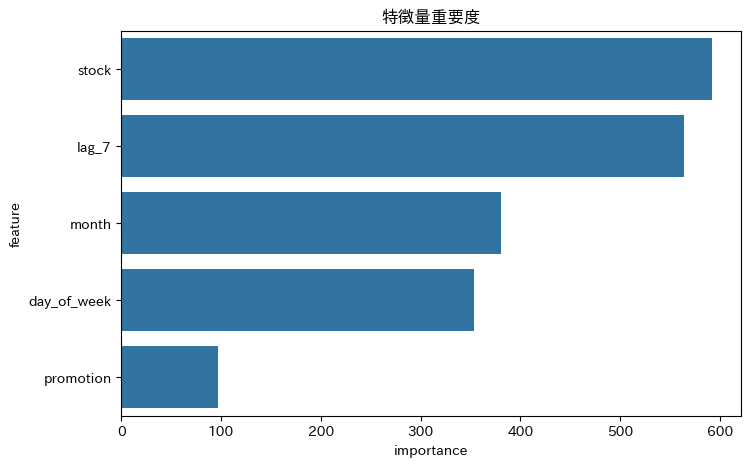

In [24]:
# =======================================================
# 8 特徴量重要度
# =======================================================

importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(data=importance, x="importance", y="feature")

plt.title("特徴量重要度")

plt.show()